# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv") #completa el código
usage = pd.read_csv("/datasets/usage.csv") #completa el código

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


In [12]:
# Proporcion de valores nulos
print(usage.isna().mean())

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
En users, las columnas con valores faltantes son city (11.7%) y churn_date (88.4%). En usage, se identificaron valores faltantes en date (0.125%), duration (55.19%) y length (44.74%).


- Indica qué harías: ¿imputar, eliminar, ignorar?
Los nulos de churn_date se conservarían porque probablemente representan clientes activos. Los valores faltantes en city requieren investigación adicional o imputación según el objetivo del análisis. En date, debido a su baja proporción (0.125%), podrían ignorarse temporalmente o investigarse más adelante para evaluar su impacto. Los nulos de duration y length parecen estar relacionados con el tipo de registro, por lo que se conservarían al formar parte de la estructura esperada de los datos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
user_id no presenta problemas aparentes. Los valores son consecutivos y actúan como identificadores únicos, por lo que no requieren modificaciones.


- La columna `age` La columna age contiene el valor -999, que no es una edad válida. Lo reemplazaría por NaN y posteriormente imputaría los valores faltantes con la mediana para evitar sesgos en el análisis.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
En duration, el percentil 75 es de aproximadamente 6.99 minutos, mientras que el valor máximo alcanza los 120 minutos. Esta diferencia es considerable, ya que el valor máximo es más de 17 veces superior al percentil 75, lo que sugiere la presencia de posibles outliers. Sin embargo, una llamada de 120 minutos sigue siendo plausible y no necesariamente indica un error en los datos. Además, se observan registros con duración de 0 minutos, los cuales podrían corresponder a llamadas perdidas o canceladas y requieren investigación adicional.

- Las columnas ...
De forma similar, en length el percentil 75 es de 64 caracteres y el máximo es de 1490 caracteres, lo que también indica posibles valores atípicos. No obstante, este valor sigue siendo posible para mensajes largos, por lo que conviene analizar su distribución antes de aplicar cualquier tratamiento.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"\nDistribución de {columna}:")
    print(users[columna].value_counts()) 



Distribución de city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Distribución de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` ...
Se encontró un valor "?" con 96 registros. Este valor no parece representar una ciudad válida, sino un marcador o dato faltante (sentinel). Estos registros deberían investigarse más adelante para decidir si se reemplazan, se imputan o se eliminan, dependiendo del análisis.

- La columna `plan` ...
Los valores observados son basico (2595 registros) y premium (1405 registros). Ambos parecen ser categorías válidas y no se observan inconsistencias evidentes, por lo que no se requiere corrección en esta columna.


In [16]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...
Contiene únicamente las categorías text y call, ambas válidas. No se detectan valores inconsistentes o faltantes. Además, se observa una mayor cantidad de registros de text que de call.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
age: se encontró el valor -999, que no representa una edad válida.
city: se encontró el valor "?" en 96 registros, probablemente utilizado como sentinel para datos faltantes.

- ¿Qué acción tomarías?
En age, reemplazar -999 directamente con la mediana.
En city, reemplazar "?" por NaN y evaluar posteriormente si conviene imputar o eliminar esos registros.
En duration y length, no se encontraron valores inválidos, pero sí posibles outliers, por lo que se recomienda analizar su distribución antes de aplicar algún tratamiento.
En type, no se encontraron valores inválidos ni inconsistencias, por lo que no se requiere ninguna acción.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce") # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Se encontraron los años 2022, 2023, 2024 y 2026 en la columna reg_date. Dado que los datos están registrados hasta 2024, el año 2026 se considera un valor fuera de rango y probablemente corresponde a un error de captura. Estos registros deberán revisarse durante la limpieza de datos y, de confirmarse el error, corregirse o eliminarse.

In [20]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.unique())

[2024.   nan]


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
En la columna date se encontró el año 2024, que es consistente con el período esperado. También aparecen valores NaN, los cuales probablemente provienen de fechas inválidas convertidas a NaT mediante pd.to_datetime(..., errors='coerce'). Estos registros deberán revisarse y tratarse como datos faltantes durante la limpieza.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Aparecen años fuera del rango esperado. En la columna reg_date se encontró el año 2026, aunque el conjunto de datos solo contiene información hasta 2024, por lo que estos registros probablemente corresponden a errores de captura.

- ¿Qué harías con ellas?
Durante la limpieza de datos, estos registros deberían identificarse y revisarse. Si no es posible determinar la fecha correcta, se recomienda tratarlos como datos inválidos y eliminarlos del análisis para evitar sesgos o conclusiones incorrectas.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median() 
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False)) 

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()]['type'].value_counts()

text    22076
Name: type, dtype: int64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()]['type'].value_counts()

call    17896
Name: type, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los valores nulos parecen depender de la variable type. Es esperable que los registros de tipo text no tengan duración (duration) y que los registros de tipo call no tengan longitud de mensaje (length). Por lo tanto, los valores faltantes parecen ser MAR y no errores de captura. Debido a que estos nulos tienen un significado válido, no se recomienda eliminar los registros. En su lugar, pueden conservarse o reemplazarse por 0 cuando sea apropiado para el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': "cant_mensajes",
    'is_call': "cant_llamadas",
    'duration': "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left") 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
print("Distribución porcentual de plan:")
print((user_profile['plan'].value_counts(normalize=True) * 100).round(2))

Distribución porcentual de plan:
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

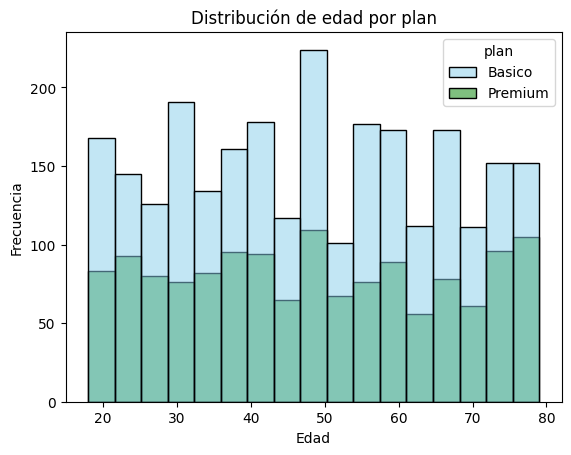

In [31]:
# Histograma para visualizar la edad (age)
sns.histplot(
     data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"]
)
plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 
- Distribución de edades es aproximadamente simétrica, con una mayor concentración de usuarios entre los 47 y 50 años. Los planes Básico y Premium abarcan un amplio rango de edades y presentan patrones similares. El plan Básico concentra la mayor proporción de usuarios (64.88%), por lo que muestra frecuencias más altas en la mayoría de los grupos de edad. Sin embargo, en las edades más jóvenes (alrededor de los 20 años) se observa una mayor presencia relativa de usuarios del plan Premium.

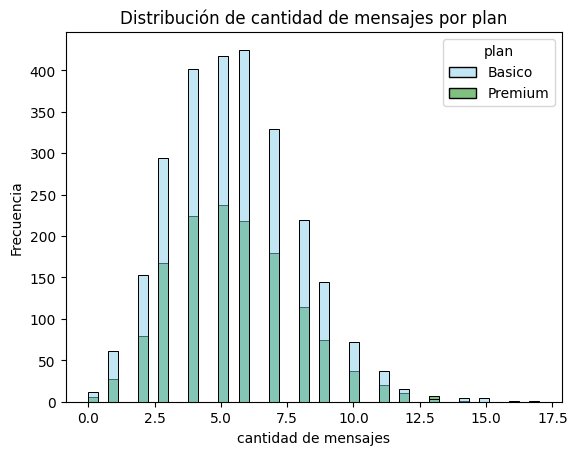

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.title("Distribución de cantidad de mensajes por plan")
plt.xlabel("cantidad de mensajes")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 
- La distribución de la cantidad de mensajes está sesgada a la derecha, lo que indica que la mayoría de los usuarios envía una cantidad relativamente baja de mensajes, mientras que un grupo más pequeño registra cantidades más altas. La mayor concentración de usuarios se encuentra aproximadamente entre 2.5 y 9.5 mensajes, con un pico cercano a los 6.5 mensajes. A partir de los 10 mensajes, la frecuencia disminuye notablemente y se observa una cola hacia los valores más altos. En cuanto a los planes, el plan Básico concentra una mayor cantidad de usuarios (64.88%) que el plan Premium (35.12%), por lo que presenta frecuencias más altas en casi todo el rango de mensajes. Sin embargo, ambos planes muestran un patrón de distribución similar.

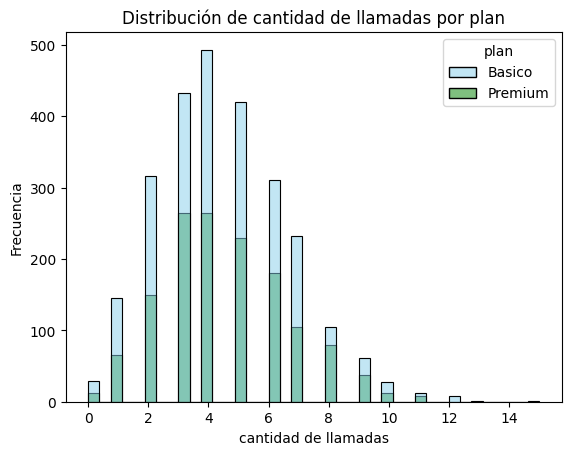

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.title("Distribución de cantidad de llamadas por plan")
plt.xlabel("cantidad de llamadas")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 
- La distribución de la cantidad de llamadas presenta un ligero sesgo a la derecha, lo cual es consistente con que la media (4.48) sea superior a la mediana (4). La mayor concentración de usuarios se encuentra entre 2 y 7 llamadas, con un pico alrededor de las 4 llamadas, seguido por 3 y 5 llamadas. A medida que aumenta la cantidad de llamadas, la frecuencia disminuye gradualmente, observándose una cola hacia los valores más altos. Aunque los valores superiores a 10 llamadas presentan una frecuencia menor, el máximo registrado alcanza las 15 llamadas. En general, los planes Básico y Premium muestran un comportamiento similar, aunque el plan Básico presenta frecuencias más altas debido a que concentra una mayor proporción de usuarios.

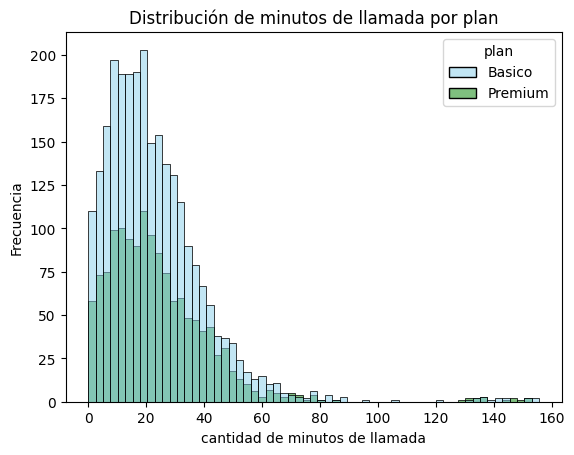

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.title("Distribución de minutos de llamada por plan")
plt.xlabel("cantidad de minutos de llamada")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 
- La variable cant_minutos_llamada está sesgada a la derecha, ya que la media (23.32) es mayor que la mediana (19.78). La mayoría de las llamadas se concentra entre 10 y 30 minutos, con un pico alrededor de los 20 minutos. A partir de los 40 minutos, la distribución forma una cola larga hacia la derecha, con pocos usuarios que alcanzan duraciones muy altas cercanas a los 150 minutos. 

- La gran diferencia entre el percentil 75 (31.4 min) y el máximo (155.7 min) evidencia la existencia de un pequeño grupo de usuarios con consumo muy elevado, lo cual podría representar una oportunidad para optimizar la estructura de planes y adaptar la oferta a usuarios intensivos. Además, el plan Básico reúne más usuarios que el Premium, aunque ambos muestran un comportamiento similar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

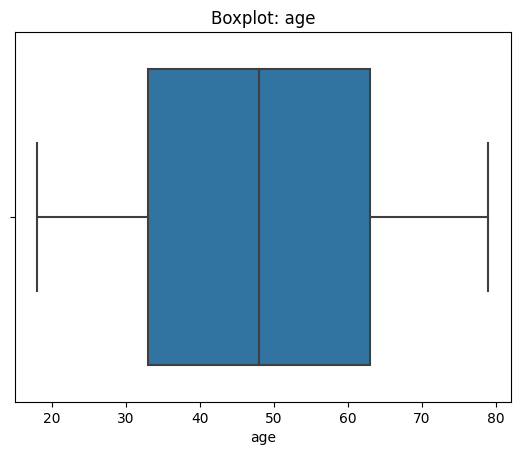

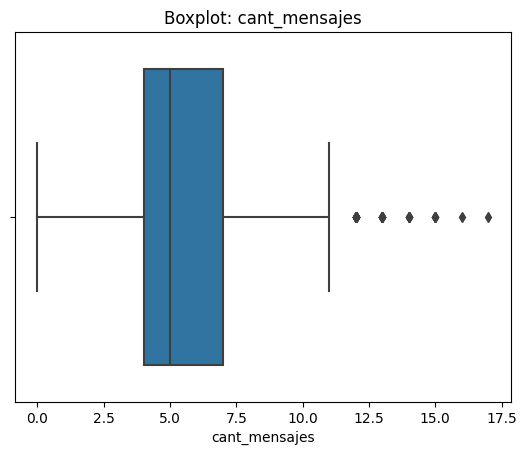

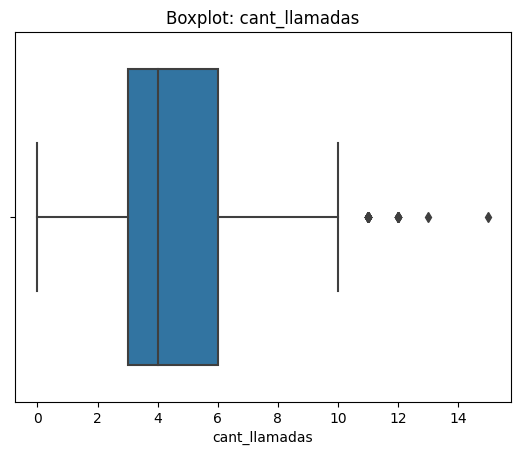

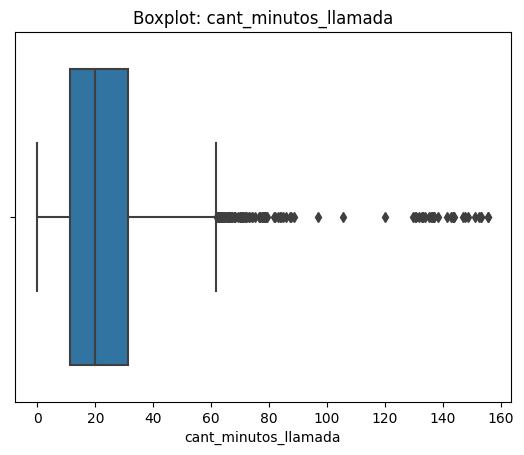

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age:no presenta outliers
  
- cant_mensajes:presenta outliers del lado derecho (valores altos desde ~11)

- cant_llamadas:presenta outliers del lado derecho (valores altos desde ~11 hasta 15-16)

- cant_minutos_llamada:presenta outliers del lado derecho (valores altos desde ~60 hasta 160)

In [36]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

limites = {}

for col in columnas_limites:
    Q1 = user_profile[col].describe()["25%"]
    Q3 = user_profile[col].describe()["75%"]
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    limites[col] = limite_superior


In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
display(user_profile[columnas_limites].describe())
print(limites)


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


{'cant_mensajes': 11.5, 'cant_llamadas': 10.5, 'cant_minutos_llamada': 61.8575}


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
 Se mantienen los outliers, porque representan usuarios más activos, no errores.

- cant_llamadas: mantener o no outliers, porqué?
 También se mantienen los outliers, son variaciones naturales del comportamiento.

- cant_minutos_llamada: mantener o no outliers, porqué?
 No hay evidencia de errores de captura
 Los valores altos representan usuarios intensivos
 Eliminar estos datos haría perder información importante del comportamiento de clientes

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)
]

valores = ["Bajo uso", "Uso medio"]

user_profile["grupo_uso"] = np.select(condiciones, valores, default="Alto uso")

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
condiciones = [
    (user_profile["age"] < 30),
    (user_profile["age"] < 60)
]

valores = ["Joven", "Adulto"]

user_profile["grupo_edad"] = np.select(condiciones, valores, default="Adulto Mayor")

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

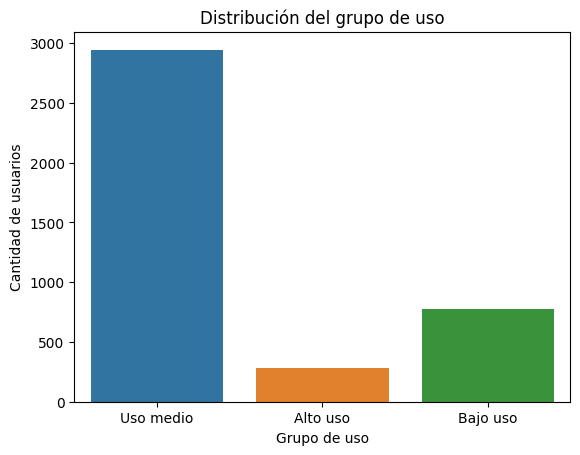

In [42]:
# Visualización de los segmentos por uso
sns.countplot(x="grupo_uso", data=user_profile)

plt.title("Distribución del grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

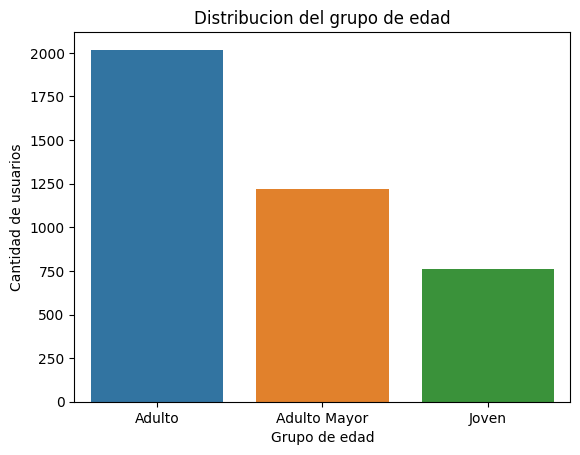

In [44]:
# Visualización de los segmentos por edad
sns.countplot(x="grupo_edad", data=user_profile)

plt.title("Distribucion del grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()

In [45]:
print(user_profile['grupo_uso'].value_counts())
print(user_profile['grupo_edad'].value_counts())

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [46]:
print((user_profile['grupo_edad'].value_counts(normalize=True) * 100).round(2))

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
En la tabla de usuarios se encontraron los siguientes problemas:
age: se detectó el valor sentinela -999, el cual no representa una edad válida.
 Este valor fue reemplazado por la mediana de la columna.
city: se encontraron 96 registros con el valor "?", los cuales fueron tratados como valores nulos (NaN).
 Esto representa aproximadamente 11.7% de los registros de la columna.
churn_date: presenta 88.35% de valores nulos, lo cual es esperado ya que corresponde a clientes que aún están activos.
reg_date: se detectaron fechas inconsistentes (año 2026), las cuales fueron marcadas como NaT.

En la tabla de uso del servicio se identificaron:

duration: presenta 55.19% de valores nulos, asociados a registros de mensajes (tipo texto).
Estos valores se conservaron ya que son esperados según el tipo de interacción.
length: presenta 44.74% de valores nulos, correspondientes a registros de llamadas.
También se conservaron, ya que son datos Missing At Random (MAR).
date: presenta una baja proporción de valores nulos (0.125%, aproximadamente 50 registros).

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron dos segmentos principales de clientes: por nivel de uso y por edad.

En el nivel de uso, la mayoría corresponde a uso medio (73.6%), seguido por bajo uso (19.5%) y finalmente alto uso (7%), lo que indica que los clientes usan el servicio de forma moderada en su mayoría.

En cuanto a la edad, predominan los adultos (50.45%), seguidos por los adultos mayores (30.55%), mientras que los jóvenes (19%) son el grupo menos frecuente.

En general, el cliente típico es un adulto con uso medio del servicio.

    
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los segmentos más valiosos para ConnectaTel son los usuarios de uso medio y los adultos, ya que representan la mayor parte de la base de clientes (73.6% y 50.45%). Esto los convierte en el grupo principal porque concentran la mayoría del uso del servicio y aportan estabilidad al negocio.

   
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Los outliers son los usuarios de alto uso (7%) y bajo uso (19.5%). Los de alto uso pueden generar más ingresos pero también mayores costos, mientras que los de bajo uso pueden indicar poco uso del servicio o riesgo de abandono. Estos segmentos representan oportunidades para mejorar la retención y la monetización.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

  Se recomienda crear planes enfocados en el uso medio, ya que es el segmento principal. También un plan básico para usuarios de bajo uso para reducir abandono y un plan premium para alto uso para aprovechar su mayor consumo. Además, se podrían incluir promociones dirigidas a jóvenes para aumentar su participación.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la columna age se encontraron valores inválidos como -999 (valores sentinela), los cuales fueron tratados como valores faltantes para evitar distorsiones en el análisis. 

- En la columna city se identificaron valores inconsistentes como “?”, y en reg_date se detectaron fechas fuera de rango (2026), los cuales fueron corregidos o ajustados durante la limpieza de datos. 


🔍 **Segmentos por Edad**
- Los adultos son el grupo predominante (50.45%), seguidos por los adultos mayores (30.55%) y los jóvenes (19%).

- Esto muestra que la base de clientes está concentrada principalmente en usuarios adultos, con menor participación de jóvenes.


📊 **Segmentos por Nivel de Uso**
-  El uso medio es el segmento dominante (73.6%), lo que indica un consumo estable del servicio.
-  El uso bajo (19.5%) también es relevante, ya que representa una parte importante de usuarios con bajo nivel de actividad, lo que puede indicar poco engagement o riesgo de baja utilización del servicio.


➡️ Esto sugiere que la base de clientes de ConnectaTel está fuertemente concentrada en usuarios de consumo medio, por lo que las estrategias deben enfocarse principalmente en este segmento mientras se buscan oportunidades de crecimiento en los extremos (alto y bajo uso).


💡 **Recomendaciones**
-  Optimizar planes para el segmento de uso medio, ya que representa la base principal de clientes.

-  Crear estrategias específicas para alto y bajo uso, enfocadas en fidelización y aumento de consumo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`